# QELM Fisher Information vs Quantum Fisher Information for Quantum State Tomography

The goal of this notebook is to quantify the Fisher information of the optimal measurement performed for estimation of each tomography parameter and compare this to the QFI as a function of the tomographic parameter

## 1. Imports

In [385]:
%matplotlib widget

In [386]:
from qsim.dynamics import HamiltonianGenerator, ExponentialPropagator, Dynamics, GKSLGenerator, RK4Propagator
from qsim.state import DensityMatrix, ObservableDetector
from qsim.lin_alg import Operator, sigmaMinus, sigmaPlus, I
from qsim.ensemble import HilbertSchmidt

from qres.qelm import QELM
import matplotlib.pyplot as plt
import numpy as np
import scipy

## 2. Reservoir Configuration

In [387]:
n_target = 1
n_reservoir = 1

t_multi = 20

#On-site energy
e_min = -2
e_max = 2

# Tunneling strength
t_min = 0.5
t_max = 1.5

# Interaction strength
v_min = 0.5
v_max = 2.5

# Pairing Strength
delta_min = 0.2
delta_max = 0.8

# Damping strength
gamma_min = 0.1
gamma_max = 0.5

# Squeezing strength

s_min = 0.5
s_max = 1

In [388]:
from functools import reduce


def interactingFermion(n_target, n_reservoir):
    dim = n_target + n_reservoir
    
    ops = []

    for i in range(dim):
        ops.append((np.random.uniform(e_min, e_max) * sigmaPlus @ sigmaMinus).changeHilbertSpace(new_dims=(2,) * dim, send_to_sites = (i,)))
        ops.append((np.random.uniform(s_min, s_max) * (sigmaPlus + sigmaMinus)).changeHilbertSpace(new_dims=(2,) * dim, send_to_sites = (i,)))
    
    for i in range(dim):
        for j in range(i):
            sigma_plus_i = sigmaPlus.changeHilbertSpace((2,)*dim, (i,))
            sigma_minus_i = sigmaMinus.changeHilbertSpace((2,)*dim, (i,))
            sigma_plus_j = sigmaPlus.changeHilbertSpace((2,)*dim, (j,))
            sigma_minus_j = sigmaMinus.changeHilbertSpace((2,)*dim, (j,))
            n_i = sigma_plus_i @ sigma_minus_i
            n_j = sigma_plus_j @ sigma_minus_j

            ops.append(np.random.uniform(t_min, t_max) * (sigma_minus_i @ sigma_plus_j + sigma_minus_j @ sigma_plus_i))
            ops.append(np.random.uniform(v_min, v_max) * n_i @ n_j)
            ops.append(np.random.uniform(delta_min, delta_max) * (sigma_plus_i @ sigma_plus_j + sigma_minus_i @ sigma_minus_j))

    return reduce(lambda x,y : x+y, ops)

In [389]:
H = interactingFermion(n_target, n_reservoir)

In [390]:

joint = False
gen = HamiltonianGenerator(H)
prop = ExponentialPropagator()
dynam = Dynamics(prop, gen)
t=1
detectors = []
for i in range(n_target, n_target + n_reservoir):
    detectors.append(ObservableDetector(sigmaPlus @ sigmaMinus, dims=(2,) * (n_target + n_reservoir), target_sites=(i,)))
    for j in range(i):
        if joint:
            n_i = (sigmaPlus @ sigmaMinus).changeHilbertSpace((2,2), (0,))
            n_j = (sigmaPlus @ sigmaMinus).changeHilbertSpace((2,2), (1,))
            detectors.append(ObservableDetector(n_i + n_j, dims=(2,) * (n_target + n_reservoir), target_sites=(i,j)))
measures = [(sigmaPlus @ sigmaMinus).changeHilbertSpace((2,) * (n_target + n_reservoir), (i,)) for i in range(n_target, n_target + n_reservoir)]

def res_func_noise(shots=-1):
    def reservoir_func(state: DensityMatrix) -> np.ndarray[float]:
        res_state = np.zeros(shape=(2**(n_reservoir),)*2)
        res_state[0][0] = 1
        total_state = state ^ DensityMatrix(res_state)
        measures = []
        for i in range(t_multi):
            total_state = dynam.evolve(total_state, ts = [t])
            for d in detectors:
                measures.append(d.detect(total_state, shots))
        return np.array(measures)
    return reservoir_func

def heisenberg_func(ops: list[Operator]) -> list[Operator]:
    res_state = np.zeros(shape=(2**(n_reservoir),)*2)
    res_state[0][0] = 1
    total_state = I(2**n_target) ^ Operator(res_state)

    evolved_ops = []

    for i in range(t_multi):
        ops = [dynam.evolveOperator(op, ts = [0], t0 = t) for op in ops]
        for op in ops:
            evolved_ops.append((op @ total_state).partialTrace((2,)*(n_target + n_reservoir), tuple([i for i in range(n_target)])))

    return evolved_ops


In [391]:
shots = [-1, 10e6, 10e2, 10e0]

qelms = [QELM(res_func_noise(shot), heisenberg_func) for shot in shots]

## 3. Training Dataset

In [392]:
import numpy as np

def density_matrix_to_vec(rho: np.ndarray) -> np.ndarray:
    """
    Flatten a Hermitian density matrix into a 1D real vector containing
    all unique real and imaginary parts.

    Layout of the returned vector:
        [ diag (N),
          Re(upper off-diagonal) (N*(N-1)/2),
          Im(upper off-diagonal) (N*(N-1)/2) ]

    Parameters
    ----------
    rho : np.ndarray, shape (N, N), complex
        Hermitian density matrix.

    Returns
    -------
    vec : np.ndarray, shape (N**2,), float
        Flattened representation.
    """
    rho = np.asarray(rho)
    if rho.ndim != 2 or rho.shape[0] != rho.shape[1]:
        raise ValueError("rho must be a square 2D array")

    N = rho.shape[0]

    # Optional sanity check for Hermiticity
    if not np.allclose(rho, rho.conj().T):
        raise ValueError("rho is not Hermitian within numerical tolerance")

    # Diagonal (purely real for a density matrix)
    diag = rho.diagonal().real

    # Upper-triangular off-diagonal entries
    iu = np.triu_indices(N, k=1)
    upper = rho[iu]
    real_upper = upper.real
    imag_upper = upper.imag

    # Concatenate into a single real vector
    vec = np.concatenate([diag, real_upper, imag_upper]).astype(float)
    return vec


def vec_to_density_matrix(vec: np.ndarray) -> np.ndarray:
    """
    Reconstruct a Hermitian matrix from the flattened real vector produced
    by `density_matrix_to_vec`.

    Parameters
    ----------
    vec : np.ndarray, shape (N**2,), float
        Flattened representation.

    Returns
    -------
    rho : np.ndarray, shape (N, N), complex
        Reconstructed Hermitian matrix.
    """
    vec = np.asarray(vec, dtype=float).ravel()

    # Infer dimension N from length N**2
    N_float = np.sqrt(vec.size)
    N = int(round(N_float))
    if N * N != vec.size:
        raise ValueError("Length of vec must be a perfect square (N**2).")

    # Number of unique off-diagonal entries in the upper triangle
    K = N * (N - 1) // 2
    expected_len = N + 2 * K
    if vec.size != expected_len:
        raise ValueError(
            f"Invalid vector length {vec.size} for any Hermitian N; "
            f"expected N + 2 * N*(N-1)/2 = N**2."
        )

    # Slice out components
    diag = vec[:N]
    real_upper = vec[N:N + K]
    imag_upper = vec[N + K:]

    # Build matrix
    rho = np.zeros((N, N), dtype=complex)
    np.fill_diagonal(rho, diag)

    iu = np.triu_indices(N, k=1)
    rho[iu] = real_upper + 1j * imag_upper
    # Fill lower triangle by Hermitian symmetry
    rho[(iu[1], iu[0])] = rho[iu].conj()

    return rho



In [393]:
import numpy as np

def generalized_gell_mann(d):
    """Generate SU(d) generators (Gell-Mann matrices)."""
    lambdas = []

    # Symmetric generators
    for i in range(d):
        for j in range(i+1, d):
            mat = np.zeros((d, d), dtype=complex)
            mat[i, j] = 1
            mat[j, i] = 1
            lambdas.append(mat)

    # Antisymmetric generators
    for i in range(d):
        for j in range(i+1, d):
            mat = np.zeros((d, d), dtype=complex)
            mat[i, j] = -1j
            mat[j, i] = 1j
            lambdas.append(mat)

    # Diagonal generators
    for k in range(1, d):
        mat = np.zeros((d, d), dtype=complex)
        for i in range(k):
            mat[i, i] = 1
        mat[k, k] = -k
        mat = mat * np.sqrt(2 / (k * (k + 1)))
        lambdas.append(mat)

    return lambdas


def density_to_bloch(rho):
    """Convert density matrix to Bloch vector."""
    d = rho.shape[0]
    lambdas = generalized_gell_mann(d)

    r = np.zeros(len(lambdas), dtype=float)

    for i, lam in enumerate(lambdas):
        r[i] = 0.5 *np.trace(rho @ lam).real

    return r

def bloch_to_density(r):
    d = int(np.sqrt(len(r) + 1))
    lambdas = generalized_gell_mann(d)

    rho = np.eye(d, dtype=complex) / d

    for i, lam in enumerate(lambdas):
        rho += r[i] * lam

    return rho

In [394]:
n_train = 100
n_test = 1000

x_train = HilbertSchmidt.generateDMBatch(2**(n_target), n=n_train)
x_test = HilbertSchmidt.generateDMBatch(2**(n_target), n=n_test)

y_train = np.array([density_to_bloch(x.matrix) for x in x_train])
y_test = np.array([density_to_bloch(x.matrix) for x in x_test])

## 4. Transform

In [395]:
[qelm.fit(x_train, y_train) for qelm in qelms]

[None, None, None, None]

In [396]:
scores = [qelm.score(x_test, y_test) for qelm in qelms]

In [397]:
scores

[array([8.28872705e-33, 6.13393507e-32, 2.80413233e-32]),
 array([8.92740368e-09, 7.85135267e-09, 1.61871117e-08]),
 array([8.53889565e-05, 8.06050695e-05, 1.58413800e-04]),
 array([0.00688654, 0.00734629, 0.01082558])]

In [398]:
import numpy as np

def observable_to_povm(O, tol=1e-10):
    """
    Convert a Hermitian observable into its projective POVM.

    Parameters
    ----------
    O : ndarray (d x d)
        Hermitian observable
        
    tol : float
        Tolerance for grouping degenerate eigenvalues

    Returns
    -------
    povm : list of ndarray
        List of POVM elements (projectors Π_k)
        
    eigvals : list
        Corresponding eigenvalues
    """
    
    # Diagonalise observable
    eigvals, eigvecs = np.linalg.eigh(O)
    
    povm = []
    unique_vals = []
    
    # Group degenerate eigenvalues
    for i, val in enumerate(eigvals):
        placed = False
        
        for j, uval in enumerate(unique_vals):
            if abs(val - uval) < tol:
                # Add projector to existing block
                v = eigvecs[:, i]
                povm[j] += np.outer(v, np.conjugate(v))
                placed = True
                break
        
        if not placed:
            unique_vals.append(val)
            v = eigvecs[:, i]
            povm.append(np.outer(v, np.conjugate(v)))
    
    povm = [Operator(op) for op in povm]

    return povm, unique_vals

In [399]:
evolved_ops = [qelm.mapOperators(measures) for qelm in qelms]

In [400]:
evolved_ops_sqrd = [qelm.mapOperators([m @ m for m in measures]) for qelm in qelms]

In [401]:
base_povm, unique_vals = observable_to_povm((sigmaPlus@sigmaMinus).matrix)

In [402]:
base_povm[1].matrix

array([[0., 0.],
       [0., 1.]])

In [403]:
povms = np.array([[base_povm[0].changeHilbertSpace((2,) * (n_target + n_reservoir), send_to_sites=(1,))], [base_povm[1].changeHilbertSpace((2,) * (n_target + n_reservoir), send_to_sites=(1,))]])

In [404]:
evolved_povms = [[qelm.mapOperators(p) for p in povms] for qelm in qelms][0]

In [405]:
eigs = np.linalg.eigvalsh(np.sum([np.outer(op, op.conj()) for op in sum([[o.matrix.T.flatten() for o in op] for op in evolved_povms], [])], axis=0))
np.max(eigs)/np.min(eigs)

np.float64(14.877080934601697)

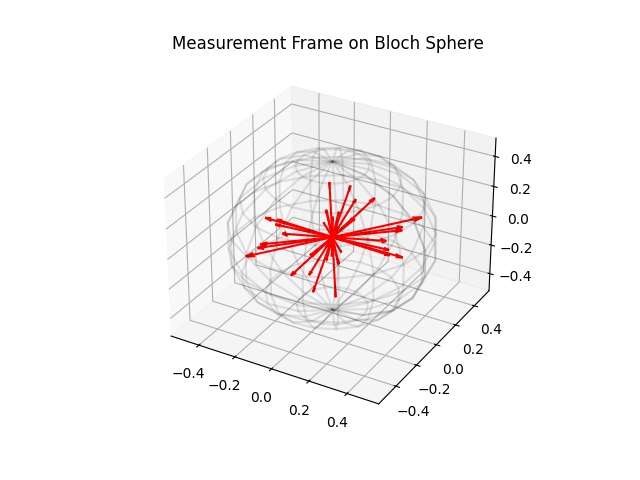

In [406]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Pauli Matrices
X = np.array([[0, 1], [1, 0]])
Y = np.array([[0, -1j], [1j, 0]])
Z = np.array([[1, 0], [0, -1]])

def get_bloch_vec(M):
    # Extract x, y, z components
    return [np.real(np.trace(M @ X)/2), 
            np.real(np.trace(M @ Y)/2), 
            np.real(np.trace(M @ Z)/2)]

# Extract vectors for all evolved POVM elements
vectors = [get_bloch_vec(op.matrix) for povm in evolved_povms for op in povm]

# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Draw a wireframe sphere for reference
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
ax.plot_wireframe(0.5*np.cos(u)*np.sin(v), 0.5*np.sin(u)*np.sin(v), 0.5*np.cos(v), color="k", alpha=0.1)

for vec in vectors:
    ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], color='r', arrow_length_ratio=0.1)

ax.set_title("Measurement Frame on Bloch Sphere")
plt.show()

In [407]:
evolved_ops[0][2].matrix

array([[ 0.30356169+4.85722573e-17j, -0.41003889+1.20477192e-01j],
       [-0.41003889-1.20477192e-01j,  0.71168454-1.38777878e-17j]])

In [408]:
evolved_povms[0][2].matrix

array([[0.69643831-2.77555756e-17j, 0.41003889-1.20477192e-01j],
       [0.41003889+1.20477192e-01j, 0.28831546+4.85722573e-17j]])

In [409]:
eff_ops = [qelm.generateEffectiveOperators(measures) for qelm in qelms]

In [410]:
eff_ops

[[Operator(dim=2), Operator(dim=2), Operator(dim=2)],
 [Operator(dim=2), Operator(dim=2), Operator(dim=2)],
 [Operator(dim=2), Operator(dim=2), Operator(dim=2)],
 [Operator(dim=2), Operator(dim=2), Operator(dim=2)]]

In [411]:
import numpy as np

def quantum_fisher_information(rho, drho, tol=1e-12):
    # Eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(rho)

    # Transform derivative into eigenbasis
    drho_eig = eigvecs.conj().T @ drho @ eigvecs

    QFI = 0.0

    for i in range(len(eigvals)):
        for j in range(len(eigvals)):
            denom = eigvals[i] + eigvals[j]

            if denom > tol:
                QFI += 2 * (np.abs(drho_eig[i, j])**2) / denom

    return np.real(QFI)

import numpy as np

def qfi_matrix(rho, drho_list, tol=1e-12):
    """
    Compute the Quantum Fisher Information (QFI) matrix for a density matrix.

    Parameters
    ----------
    rho : (d,d) ndarray
        Density matrix at parameter point θ
    drho_list : list of (d,d) ndarray
        List of derivatives ∂ρ/∂θ_i
    tol : float
        Threshold to avoid division by zero for small eigenvalues

    Returns
    -------
    F : (p,p) ndarray
        QFI matrix
    """

    # Diagonalise rho
    eigvals, eigvecs = np.linalg.eigh(rho)


    # Transform derivatives into eigenbasis
    # drho_eig[i] = V† (∂ρ_i) V
    Vdag = eigvecs.conj().T
    drho_eig = [Vdag @ d @ eigvecs for d in drho_list]

    p = len(drho_list)
    d = rho.shape[0]

    F = np.zeros((p, p), dtype=np.float64)

    # Precompute denominator matrix
    lam_sum = eigvals[:, None] + eigvals[None, :]

    # Avoid division by zero
    mask = lam_sum > tol
    inv_lam_sum = np.zeros_like(lam_sum)
    inv_lam_sum[mask] = 2.0 / lam_sum[mask]

    # Compute QFI matrix
    for i in range(p):
        for j in range(p):
            A = drho_eig[i]
            B = drho_eig[j]

            # Elementwise formula
            prod = A * B.conj()

            term = np.zeros_like(prod, dtype=np.complex128)
            term[mask] = (2.0 / lam_sum[mask]) * prod[mask]

            F[i, j] = np.real(np.sum(term))

    return F

import numpy as np

def rld_qfi_matrix1(rho, drho_list, tol=1e-2):
    rho_inv = scipy.linalg.inv(rho)

    Ls = [rho_inv @ drho for drho in drho_list]

    p = len(drho_list)
    F = np.zeros((p, p), dtype=np.complex128)

    for i, L1 in enumerate(Ls):
        for j, L2 in enumerate(Ls):
            F[i][j] = np.trace(rho @ L1 @ L2.conj().T)

    return F

def rld_qfi_matrix(rho, drho_list, tol=1e-12):
    # Invert rho safely
    eigvals, eigvecs = np.linalg.eigh(rho)
    
    # Regularise (since inverse needed)
    eigvals = np.clip(eigvals, tol, None)
    rho_inv = eigvecs @ np.diag(1.0 / eigvals) @ eigvecs.conj().T

    p = len(drho_list)
    F = np.zeros((p, p), dtype=np.complex128)

    for i in range(p):
        for j in range(p):
            F[i, j] = np.trace(
                drho_list[i] @ rho_inv @ drho_list[j] @ rho_inv
            )

    return F

In [412]:
import numpy as np

def fisher_information_observable(rho, drho, O, tol=1e-10):
    # Diagonalise observable
    eigvals, eigvecs = np.linalg.eigh(O)

    F = 0.0

    # Loop over projectors |k><k|
    for k in range(len(eigvals)):
        v = eigvecs[:, k]

        # Projector expectation values
        p = np.real(v.conj().T @ rho @ v)
        dp = np.real(v.conj().T @ drho @ v)

        if p > tol:
            F += (dp**2) / p

    return F


In [413]:
import numpy as np

def fisher_information_matrix(rho, drho, O):
    """
    Fisher matrix contribution from ONE observable and ONE shot.

    Parameters
    ----------
    rho : (d x d) ndarray
        Density matrix
        
    drho : list of ndarray
        [∂ρ/∂θ_0, ∂ρ/∂θ_1, ∂ρ/∂θ_2]
        
    O : (d x d) ndarray
        Hermitian observable

    Returns
    -------
    F : (k x k) ndarray
        Fisher information contribution
    """
    
    k = len(drho)
    F = np.zeros((k, k), dtype=float)
    
    # Diagonalise observable
    eigvals, eigvecs = np.linalg.eigh(O)
    
    for i in range(len(eigvals)):
        v = eigvecs[:, i]
        M = np.outer(v, np.conjugate(v))  # projector
        
        # Probability
        p = np.real(np.trace(rho @ M))
        if p <= 1e-12:
            continue
        
        # Derivatives of probability
        dp = np.array([
            np.real(np.trace(d @ M)) for d in drho
        ])
        
        # Fisher contribution
        F += np.outer(dp, dp) / p

    return F

import numpy as np

def fisher_information_matrix_povm(rho, drho, povm):
    """
    Fisher information matrix for ONE POVM and ONE shot.

    Parameters
    ----------
    rho : ndarray (d x d)
        Density matrix
        
    drho : list of ndarray
        [∂ρ/∂θ_0, ∂ρ/∂θ_1, ∂ρ/∂θ_2]
        
    povm : list of ndarray
        POVM elements [M_x]

    Returns
    -------
    F : ndarray (k x k)
        Fisher information matrix (single-shot contribution)
    """
    
    k = len(drho)
    F = np.zeros((k, k), dtype=float)
    
    for M in povm:
        # Probability
        p = np.real(np.trace(rho @ M))
        if p <= 1e-12:
            continue  # avoid division issues
        
        # Derivatives of probability
        dp = np.array([
            np.real(np.trace(d @ M)) for d in drho
        ])
        
        # Fisher contribution
        F += np.outer(dp, dp) / p

    return F

In [414]:
import numpy as np

def random_physical_bloch_vector(d, rng=None):
    """
    Generate a random generalized Bloch vector for dimension d
    that is guaranteed to correspond to a physical state.

    Assumes the convention
        rho = I/d + sum_a r_a lambda_a
    with Tr(lambda_a lambda_b) = 2 delta_ab.

    The guaranteed-physical condition used is
        ||r|| <= 1 / sqrt(2 d (d - 1))

    Parameters
    ----------
    d : int
        Hilbert-space dimension.
    rng : np.random.Generator or None
        Random number generator.

    Returns
    -------
    r : np.ndarray
        Real Bloch vector of length d^2 - 1.
    """
    if d < 2:
        raise ValueError("d must be at least 2")

    if rng is None:
        rng = np.random.default_rng()

    n = d**2 - 1
    r_max = 1.0 / np.sqrt(2 * d * (d - 1))

    # random direction
    v = rng.normal(size=n)
    v /= np.linalg.norm(v)

    # radius distributed uniformly in the ball
    u = rng.random()
    radius = r_max * u**(1 / n)

    return radius * v

In [415]:
qelm_i = 0
i = 3

In [416]:
import copy
from tabnanny import check

def checkLegit(state: DensityMatrix, t):
    if not state.isLegitimate():
        print('Invalid Density Matrix')
        if round(state.trace().real,5) != 1:
            print(f'Trace: {round(state.trace().real,5)}')
        if not state.isSelfAdjoint():
            print('State not self-adjoint')
        if not state.isSemiPositive():
            print(f'State min eig: {min(np.linalg.eigvals(state.matrix))}')

def plotFisherVsQFI(state, drhos, qelm_measure_sets, nrows, ncols, figsize):
    dim = int(len(drhos)**0.5) + 1
    fig, axes = plt.subplots(nrows = nrows, ncols = ncols, figsize=figsize, dpi=200)

    for x, qelm_measures in enumerate(qelm_measure_sets):
        for index, (drho, qelm_measure) in enumerate(zip(drhos, qelm_measures)):
            ax = np.array(axes).flatten()[index]
            mag = 0
            for i in range(state.shape[0]):
                if i!= index:
                    mag += state[i]**2
            d = 2**n_target
            max_val = ((d-1)/(2*d) - mag)**0.5
            #max_val = ((1/(2*d*(d-1))) - mag)**0.5
            qfis = []
            fis = []
            cut_off = 0.9
            thetas = np.linspace(-max_val* cut_off, max_val * cut_off, 50)
            for theta in thetas:
                new_state = copy.deepcopy(state)
                new_state[index] = theta
                rho = bloch_to_density(new_state)
                checkLegit(DensityMatrix(rho),0)
                qfis.append(quantum_fisher_information(copy.deepcopy(rho), drho))
                if qfis[-1] > 10:
                    print(new_state)
                fis.append(fisher_information_observable(copy.deepcopy(rho), drho, qelm_measure.matrix))
            
            if x == 0:
                ax.plot(thetas, qfis, label='QFI', linestyle='--')
            if shots[x] == -1:
                ax.plot(thetas, fis, label=r'$N_{s}=\infty, r_2=10^{' + str(np.round(np.log10(scores[x][index]),1)) + r'}$', marker='x') 
            else:
                ax.plot(thetas, fis, label=r'$N_{s}=10^{' + str(int(np.log10(shots[x]))) + r'}, r_2=10^{' + str(np.round(np.log10(scores[x][index]),1)) + r'}$')
            if index % ncols == 0:
                ax.set_ylabel('FI')
            ax.set_xlabel(r'$\lambda_{' + str(index + 1) + r'}$')
            ax.legend()

    fig.suptitle(r'QFI vs FI for QELM effective observables estimating qubit Bloch vector coefficients $\lambda_i$')
    fig.subplots_adjust(top=0.95)

def plotFisherVsQFIMeasures(state, drhos, measures, nrows, ncols, figsize):
    dim = int(len(drhos)**0.5) + 1
    fig, axes = plt.subplots(nrows = nrows, ncols = ncols, figsize=figsize, dpi=200)

    for index, drho in enumerate(drhos):
        ax = np.array(axes).flatten()[index]
        mag = 0
        for i in range(state.shape[0]):
            if i!= index:
                mag += state[i]**2
        d = 2**n_target
        max_val = ((d-1)/(2*d) - mag)**0.5
        #max_val = ((1/(2*d*(d-1))) - mag)**0.5
        qfis = []
        fis = []
        cut_off = 1
        thetas = np.linspace(-max_val* cut_off, max_val * cut_off, 50)
        for theta in thetas:
            new_state = copy.deepcopy(state)
            new_state[index] = theta
            rho = bloch_to_density(new_state)
            checkLegit(DensityMatrix(rho),0)
            qfis.append(quantum_fisher_information(copy.deepcopy(rho), drho))
            if qfis[-1] > 10:
                print(new_state)
            fis.append(sum([fisher_information_observable(copy.deepcopy(rho), drho, m.matrix) for m in measures])/len(measures))
        
        ax.plot(thetas, qfis, label='QFI', linestyle='--')
        ax.plot(thetas, fis, label=r'FI', marker='x') 
        if index % ncols == 0:
            ax.set_ylabel('FI')
        ax.set_xlabel(r'$\lambda_{' + str(index + 1) + r'}$')
        ax.legend()

    fig.suptitle(r'QFI vs FI for QELM effective observables estimating qubit Bloch vector coefficients $\lambda_i$')
    fig.subplots_adjust(top=0.95)

[-0.44243614 -0.14756546  0.124341  ]
[-0.42360907 -0.14756546  0.124341  ]
[-0.404782   -0.14756546  0.124341  ]
[-0.38595493 -0.14756546  0.124341  ]
[-0.36712786 -0.14756546  0.124341  ]
[ 0.36712786 -0.14756546  0.124341  ]
[ 0.38595493 -0.14756546  0.124341  ]
[ 0.404782   -0.14756546  0.124341  ]
[ 0.42360907 -0.14756546  0.124341  ]
[ 0.44243614 -0.14756546  0.124341  ]
[-0.20484258 -0.42092629  0.124341  ]
[-0.20484258 -0.40301453  0.124341  ]
[-0.20484258 -0.38510278  0.124341  ]
[-0.20484258 -0.36719102  0.124341  ]
[-0.20484258 -0.34927926  0.124341  ]
[-0.20484258  0.34927926  0.124341  ]
[-0.20484258  0.36719102  0.124341  ]
[-0.20484258  0.38510278  0.124341  ]
[-0.20484258  0.40301453  0.124341  ]
[-0.20484258  0.42092629  0.124341  ]
[-0.20484258 -0.14756546 -0.41396744]
[-0.20484258 -0.14756546 -0.3963518 ]
[-0.20484258 -0.14756546 -0.37873617]
[-0.20484258 -0.14756546 -0.36112053]
[-0.20484258 -0.14756546 -0.3435049 ]
[-0.20484258 -0.14756546  0.3435049 ]
[-0.20484258

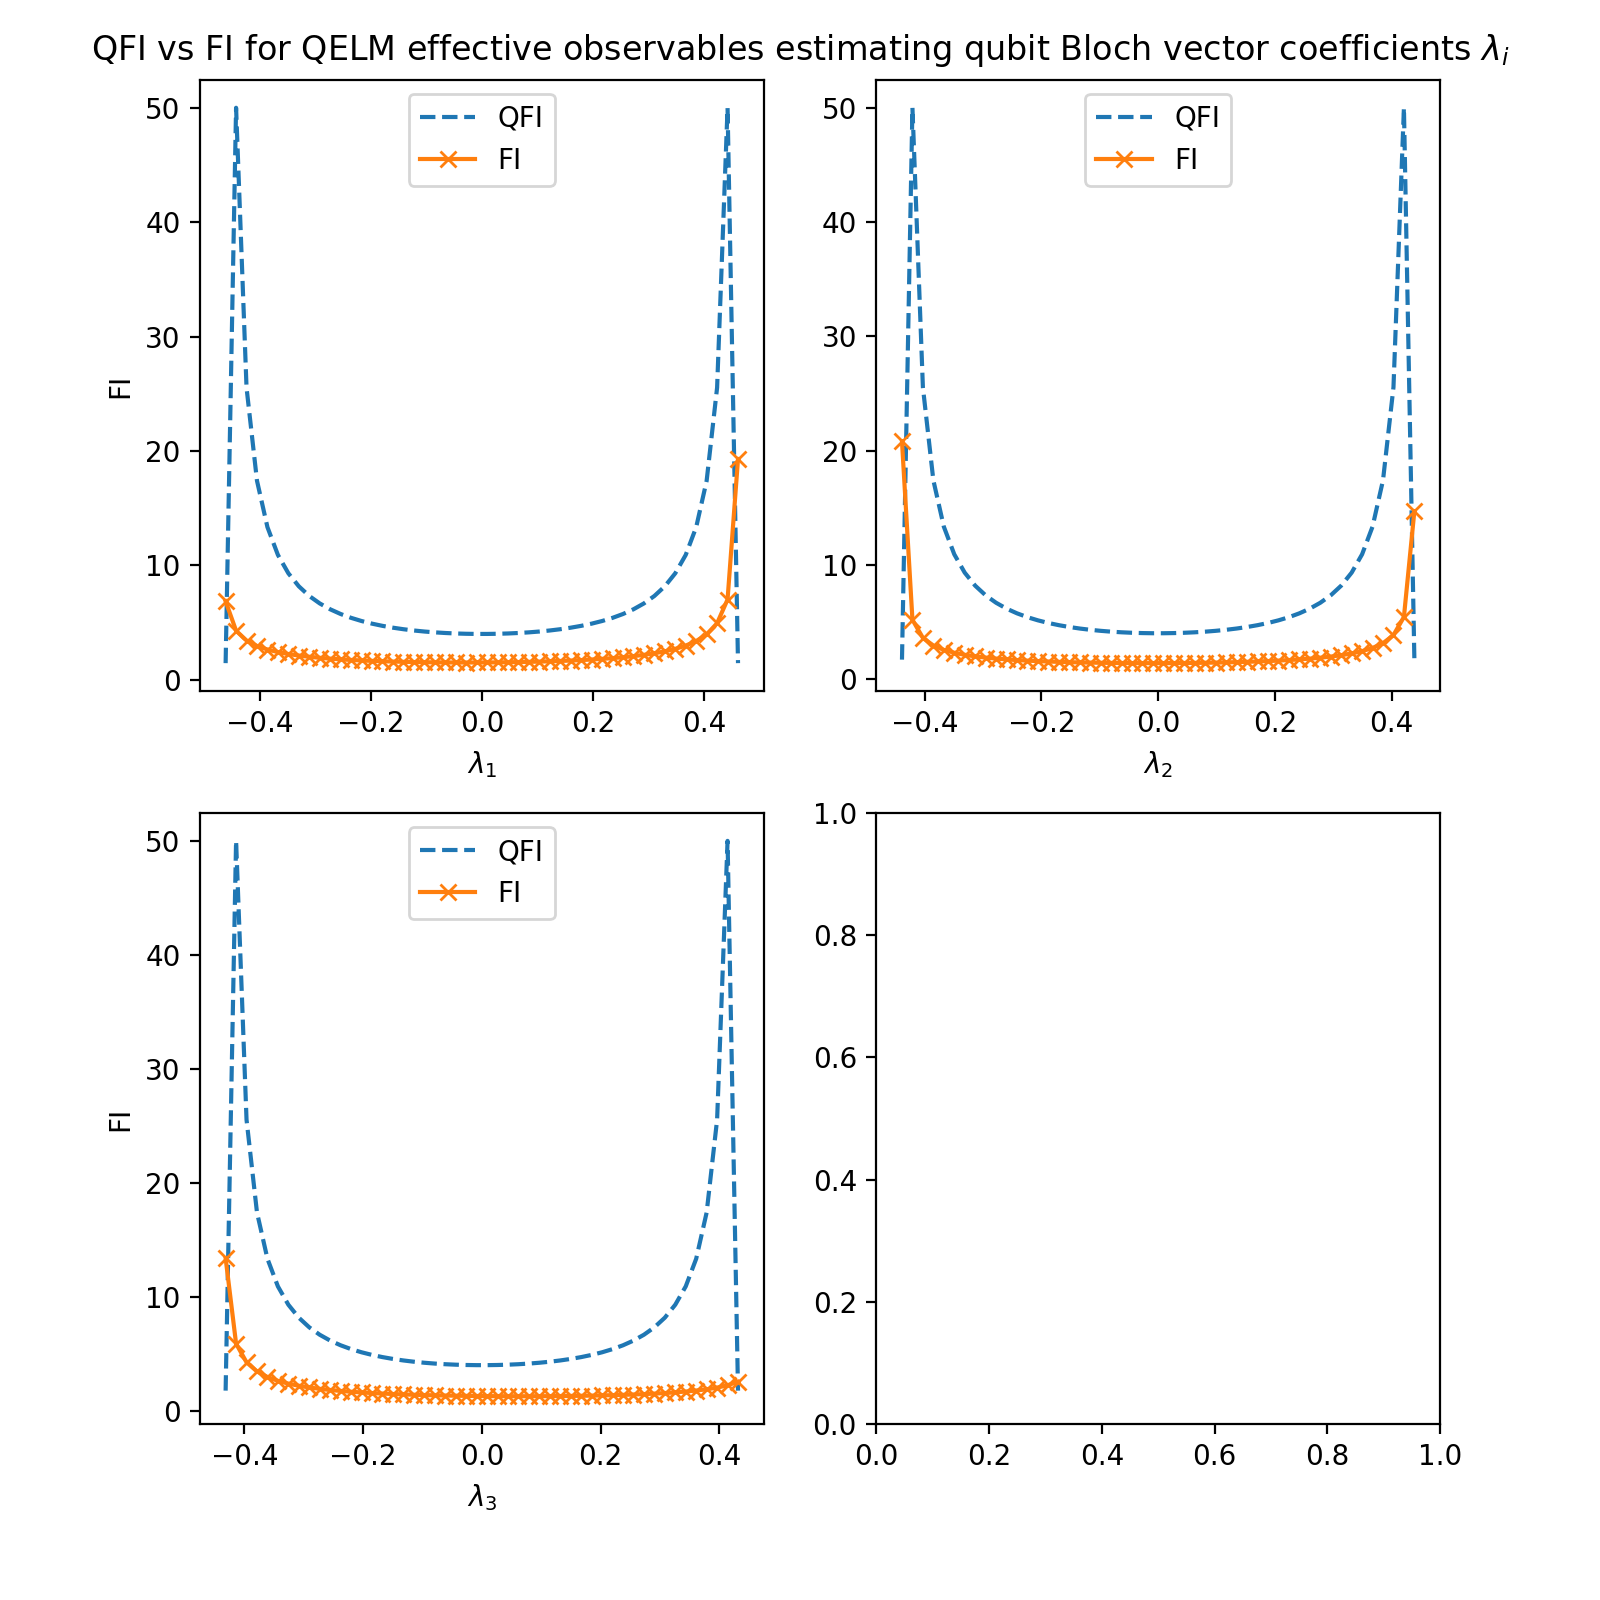

In [417]:
plotFisherVsQFIMeasures(y_test[0], generalized_gell_mann(2), evolved_ops[0], 2, 2, figsize=(8,8))

[-0.41513689 -0.14756546  0.124341  ]
[-0.39819253 -0.14756546  0.124341  ]
[-0.38124816 -0.14756546  0.124341  ]
[-0.3643038  -0.14756546  0.124341  ]
[ 0.3643038  -0.14756546  0.124341  ]
[ 0.38124816 -0.14756546  0.124341  ]
[ 0.39819253 -0.14756546  0.124341  ]
[ 0.41513689 -0.14756546  0.124341  ]
[-0.20484258 -0.39495424  0.124341  ]
[-0.20484258 -0.37883366  0.124341  ]
[-0.20484258 -0.36271308  0.124341  ]
[-0.20484258 -0.3465925   0.124341  ]
[-0.20484258  0.3465925   0.124341  ]
[-0.20484258  0.36271308  0.124341  ]
[-0.20484258  0.37883366  0.124341  ]
[-0.20484258  0.39495424  0.124341  ]
[-0.20484258 -0.14756546 -0.38842477]
[-0.20484258 -0.14756546 -0.3725707 ]
[-0.20484258 -0.14756546 -0.35671662]
[-0.20484258 -0.14756546 -0.34086255]
[-0.20484258 -0.14756546  0.34086255]
[-0.20484258 -0.14756546  0.35671662]
[-0.20484258 -0.14756546  0.3725707 ]
[-0.20484258 -0.14756546  0.38842477]
[-0.41513689 -0.14756546  0.124341  ]
[-0.39819253 -0.14756546  0.124341  ]
[-0.38124816

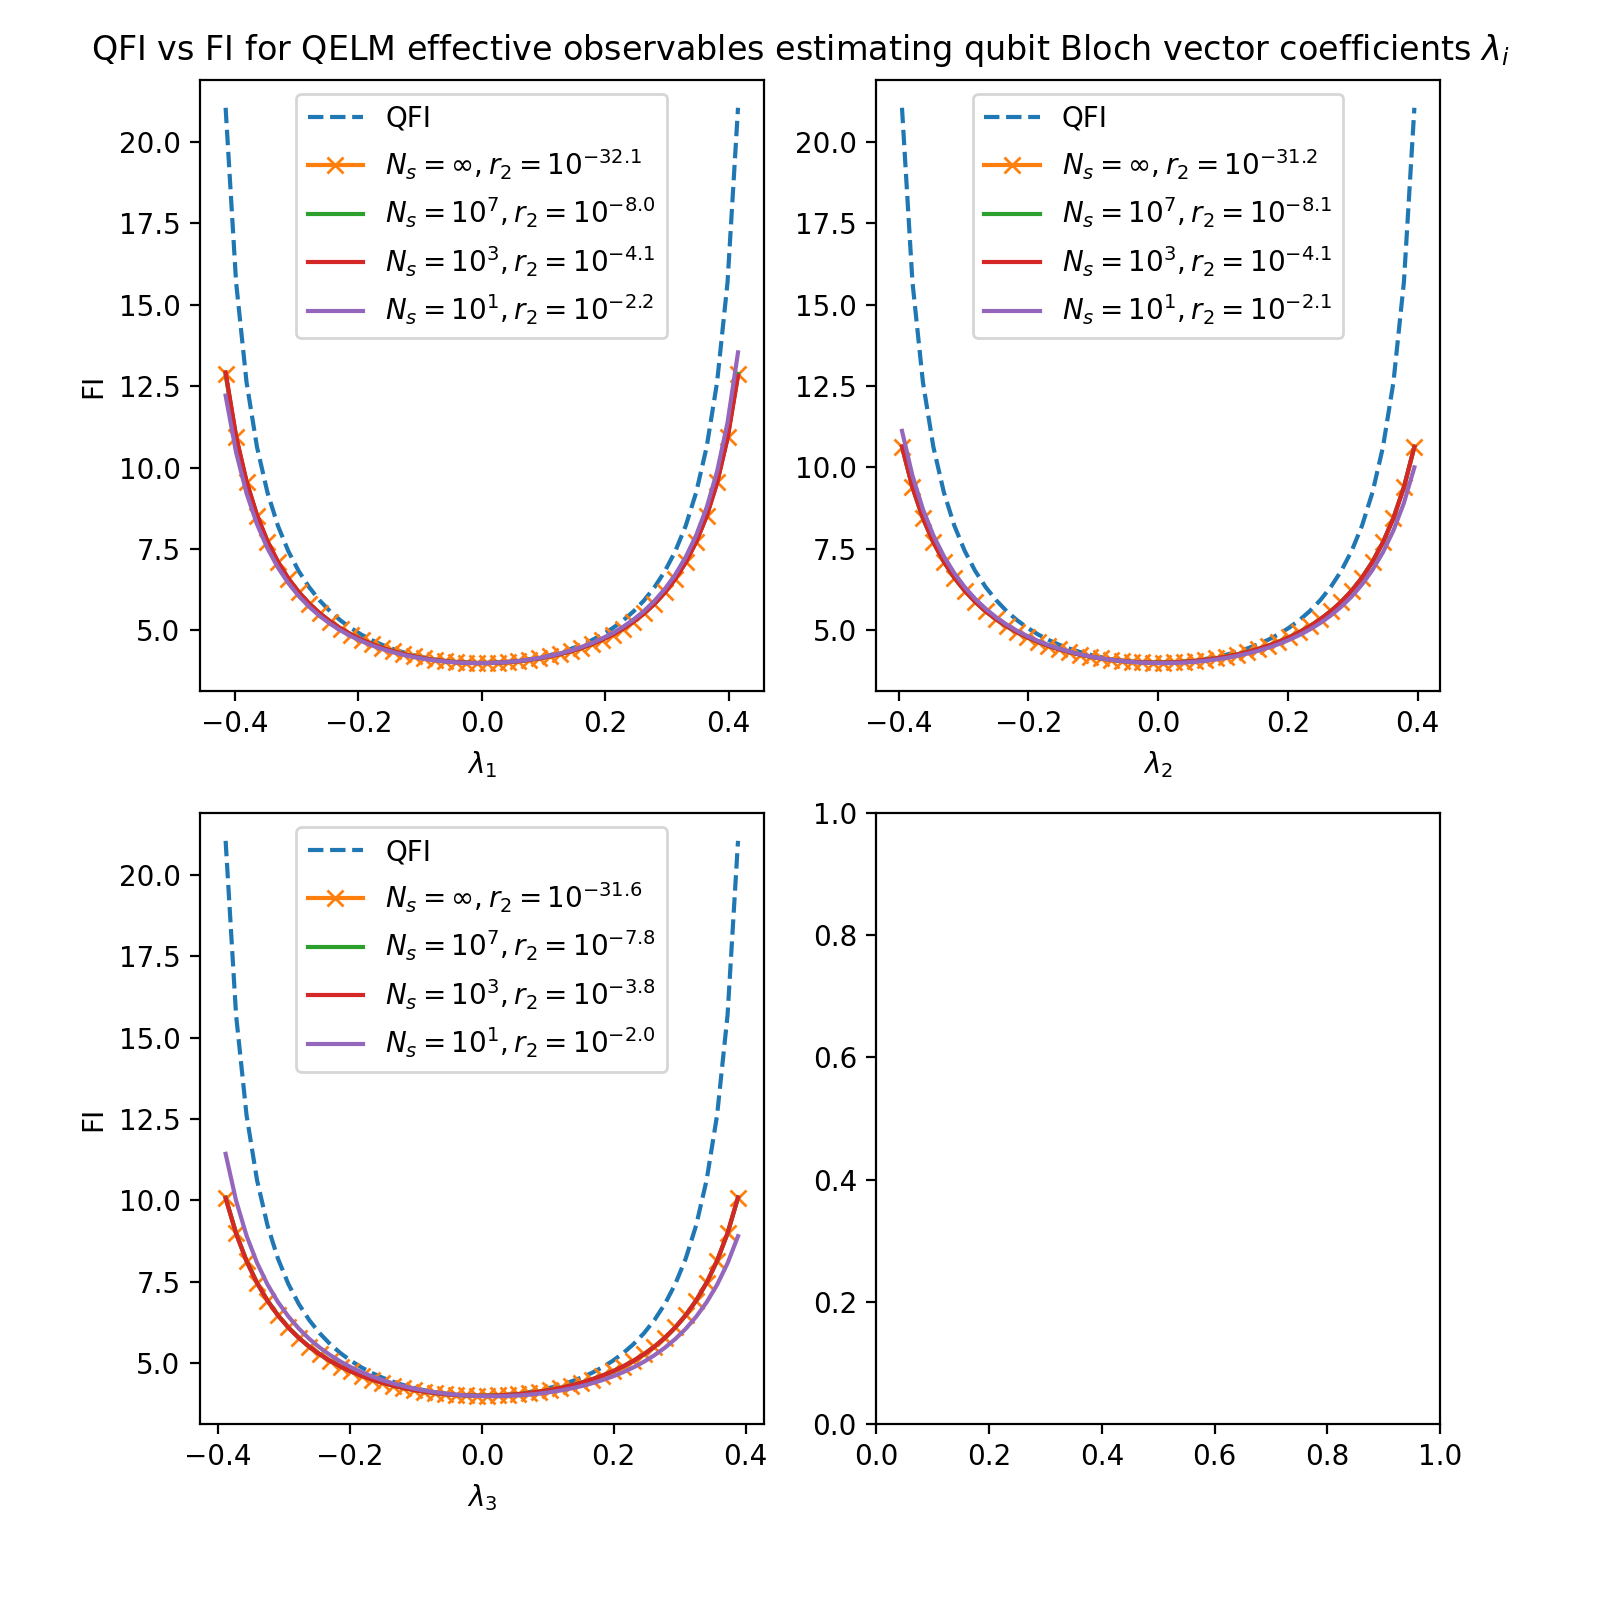

In [418]:
plotFisherVsQFI(y_test[0], generalized_gell_mann(2), eff_ops, 2, 2, figsize=(8,8))

In [419]:
def compute_scalar(r, ops):
    rho = bloch_to_density(r)
    #return np.trace(np.linalg.inv(qfi_matrix(rho, generalized_gell_mann(2**n_target)))) - np.trace(np.linalg.inv(rld_qfi_matrix1(rho, generalized_gell_mann(2**n_target))))
    return np.trace(np.linalg.inv(rld_qfi_matrix1(rho, generalized_gell_mann(2**n_target)))) - np.trace(np.linalg.inv(fisher_information_matrix(rho, generalized_gell_mann(2**n_target), [op.matrix for op in ops])))

In [420]:
def compute_scalar2(r, ops):
    rho = bloch_to_density(r)
    #return np.trace(np.linalg.inv(qfi_matrix(rho, generalized_gell_mann(2**n_target)))) - np.trace(np.linalg.inv(rld_qfi_matrix1(rho, generalized_gell_mann(2**n_target))))
    qfi = np.trace(np.linalg.inv(len(ops) * rld_qfi_matrix1(rho, generalized_gell_mann(2**n_target))))
    fi = np.trace(np.linalg.inv(np.diag([sum([fisher_information_observable(rho, g, m.matrix) for m in ops]) for g in generalized_gell_mann(2**n_target)])))
    return  (fi-qfi)/qfi

In [421]:
def compute_multiparameter_var_bound(r, ops):
    rho = bloch_to_density(r)
    #return np.trace(np.linalg.inv(qfi_matrix(rho, generalized_gell_mann(2**n_target)))) - np.trace(np.linalg.inv(rld_qfi_matrix1(rho, generalized_gell_mann(2**n_target))))
    qfi = np.trace(np.linalg.inv(rld_qfi_matrix1(rho, generalized_gell_mann(2**n_target))))
    fi = np.trace(np.linalg.inv(np.diag([sum([fisher_information_observable(rho, g, m.matrix) for m in ops]) for g in generalized_gell_mann(2**n_target)])))
    return  fi

def compute_multiparameter_var_bound2(r, ops):
    rho = bloch_to_density(r)
    #return np.trace(np.linalg.inv(qfi_matrix(rho, generalized_gell_mann(2**n_target)))) - np.trace(np.linalg.inv(rld_qfi_matrix1(rho, generalized_gell_mann(2**n_target))))
    qfi = np.trace(np.linalg.inv(rld_qfi_matrix1(rho, generalized_gell_mann(2**n_target))))
    fi = np.trace(np.linalg.inv(np.sum([fisher_information_matrix(rho, generalized_gell_mann(2), op.matrix) for op in ops],axis=0)))
    return  fi

def compute_multiparameter_var_bound3(r, ops):
    rho = bloch_to_density(r)
    #return np.trace(np.linalg.inv(qfi_matrix(rho, generalized_gell_mann(2**n_target)))) - np.trace(np.linalg.inv(rld_qfi_matrix1(rho, generalized_gell_mann(2**n_target))))
    qfi = np.trace(np.linalg.inv(rld_qfi_matrix1(rho, generalized_gell_mann(2**n_target))))
    fi = np.trace(np.linalg.inv(np.sum(np.array([fisher_information_matrix_povm(bloch_to_density(r), generalized_gell_mann(2), [ops[0][i].matrix, ops[1][i].matrix]) for i in range(6)]),axis=0)))
    return  fi

In [422]:
def compute_scalar4(r, ops):
    rho = DensityMatrix(bloch_to_density(r))
    r_est = np.array([(rho @ op).trace() for op in ops])
    return  np.mean(np.abs(r-r_est))

In [423]:
def compute_scalar_var(r, op):
    rho = DensityMatrix(bloch_to_density(r))
    return  -(rho @ op).trace().real**2 + (rho @ op @ op).trace().real

In [424]:
def compute_scalar_var_eff(r, op, op_sqrd):
    rho = DensityMatrix(bloch_to_density(r))
    return  -(rho @ op).trace().real**2 + (rho @ op_sqrd).trace().real

In [425]:
def plane_from_angles(theta, phi):
    n = np.array([
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(theta)
    ])
    return n / np.linalg.norm(n)

In [426]:
def plane_basis(n):
    # pick a vector not parallel to n
    if abs(n[2]) < 0.9:
        a = np.array([0, 0, 1])
    else:
        a = np.array([0, 1, 0])

    u = np.cross(n, a)
    u /= np.linalg.norm(u)

    v = np.cross(n, u)

    return u, v

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 6 is different from 2)

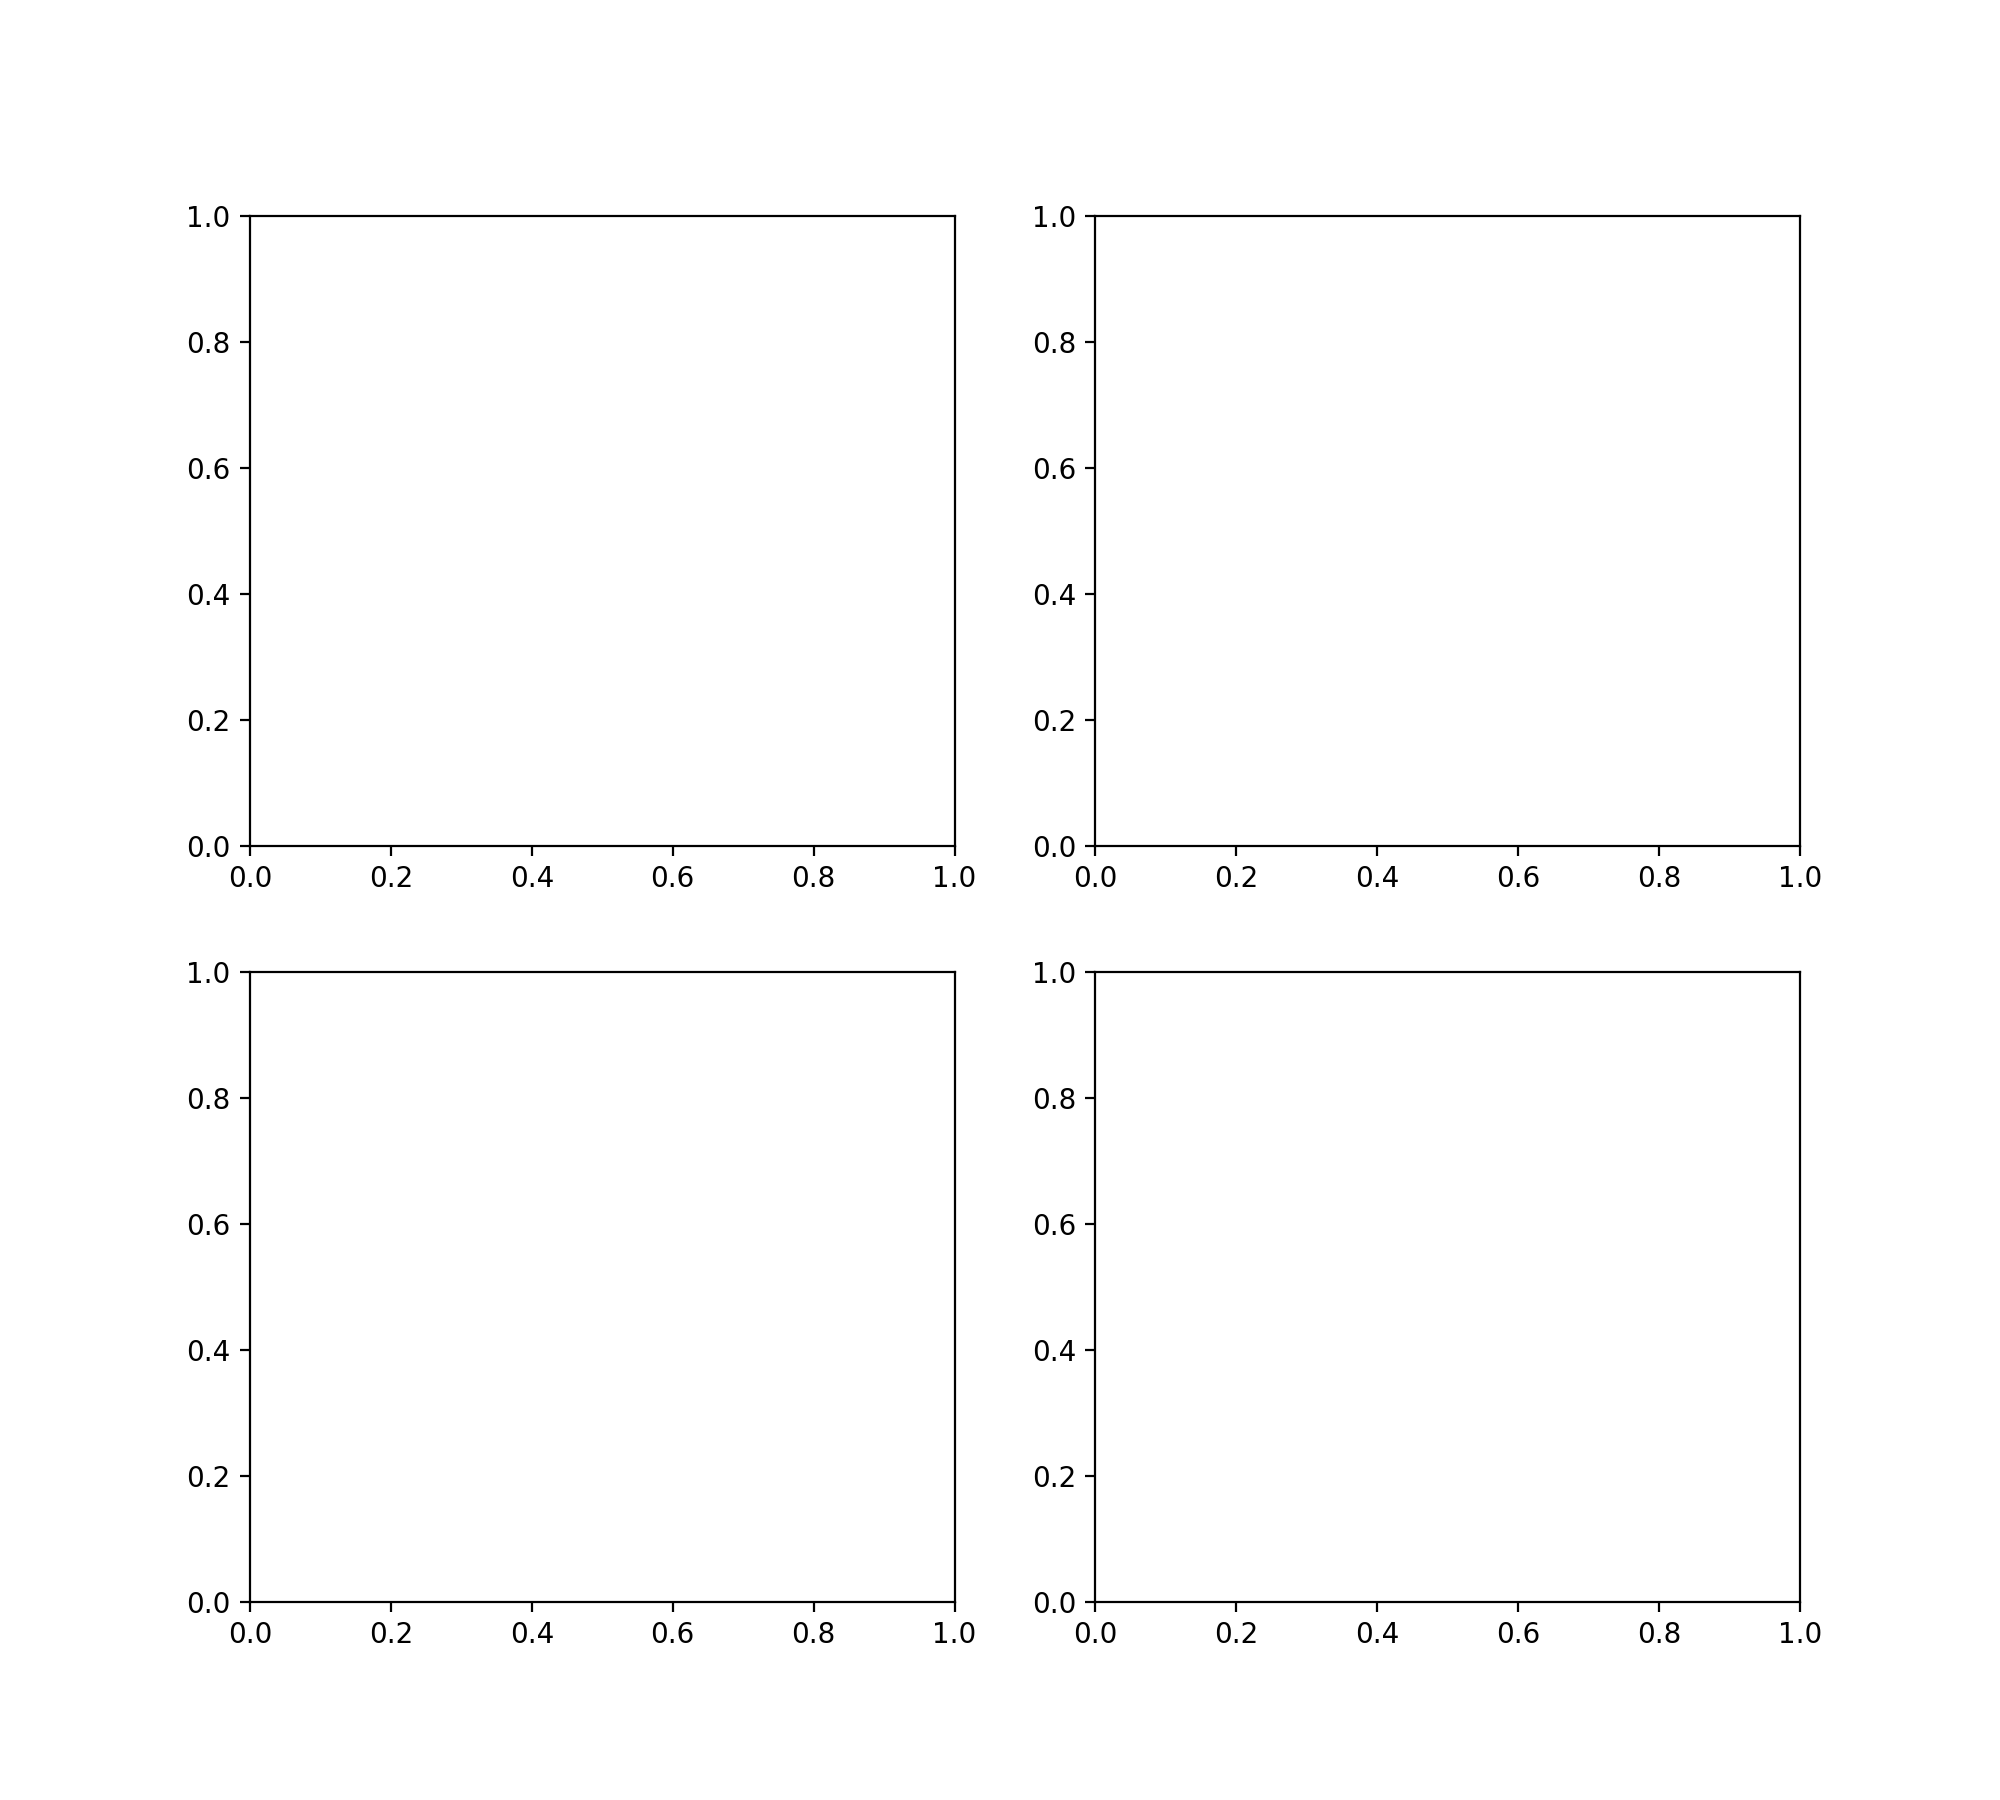

In [427]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.pi / 4   # adjust tilt
phi   = np.pi / 4   # adjust rotation
n = plane_from_angles(theta, phi)
u, v = plane_basis(n)

fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize=(10,9), dpi=200)

for pos, ops in enumerate(eff_ops):

    # --- Grid in plane coordinates ---
    res = 50
    s = np.linspace(-0.5, 0.5, res)
    t0 = np.linspace(-0.5, 0.5, res)
    S, T = np.meshgrid(s, t0)

    values = np.zeros_like(S)
    mask = np.zeros_like(S, dtype=bool)

    # --- Sample points in the plane ---
    for i in range(res):
        for j in range(res):
            r = S[i, j] * u + T[i, j] * v

            if np.linalg.norm(r) <= 0.5:
                values[i, j] = compute_scalar(r, ops)
                mask[i, j] = True
            else:
                values[i, j] = np.nan

    # --- Plot ---
    ax = axes[pos//2][pos%2]
    im = ax.imshow(values, extent=[-0.5,0.5,-0.5,0.5], origin='lower', cmap='viridis')
    fig.colorbar(im, label=r'$\Delta_{FI} = QFI - FI$', ax=ax)
    if pos == 0:
        ax.set_title(r'$N_{shots} = \infty$')
    else:
        ax.set_title(r'$N_{shots} = 10^{' + str(int(np.log10(shots[pos]))) + r'}$')
    ax.set_xlabel('Axis 1')
    ax.set_ylabel('Axis 2')

fig.suptitle(r'$\Delta_{FI}$ on Bloch sphere cross-section')
fig.subplots_adjust(top=0.93)

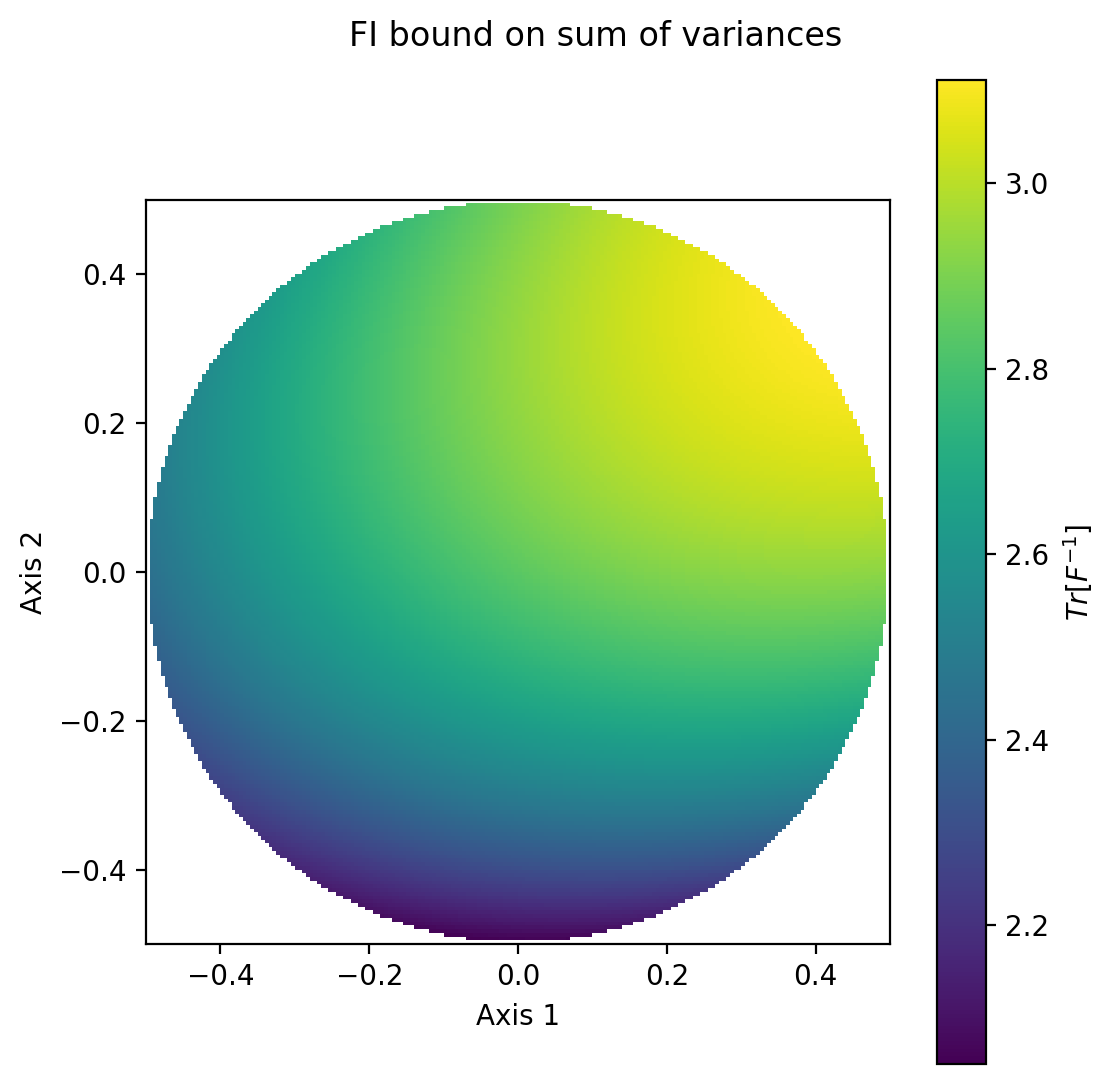

In [ ]:
from attr import evolve
import numpy as np
import matplotlib.pyplot as plt

#theta = np.pi / 2   # adjust tilt
#phi   = np.pi / 3   # adjust rotation
n = plane_from_angles(theta, phi)
u, v = plane_basis(n)

fig, ax = plt.subplots( figsize=(6,6), dpi=200)


# --- Grid in plane coordinates ---
res = 200
s = np.linspace(-0.5, 0.5, res)
t0 = np.linspace(-0.5, 0.5, res)
S, T = np.meshgrid(s, t0)

values = np.zeros_like(S)
mask = np.zeros_like(S, dtype=bool)

# --- Sample points in the plane ---
for i in range(res):
    for j in range(res):
        r = S[i, j] * u + T[i, j] * v

        if np.linalg.norm(r) <= 0.5:
            #values[i, j] = compute_multiparameter_var_bound2(r, evolved_ops[0]).real
            values[i, j] = compute_multiparameter_var_bound3(r, evolved_povms).real
            mask[i, j] = True
        else:
            values[i, j] = np.nan

# --- Plot ---
im = ax.imshow(values, extent=[-0.5,0.5,-0.5,0.5], origin='lower', cmap='viridis')
fig.colorbar(im, label=r'$Tr[F^{-1}]$', ax=ax)
ax.set_xlabel('Axis 1')
ax.set_ylabel('Axis 2')

fig.suptitle(r'FI bound on sum of variances')
fig.subplots_adjust(top=0.93)


In [ ]:
np.mean(qelms[1]._reg.coeff **2, axis=0)

array([0.91439051, 0.82280545, 0.53096368])

In [ ]:
eff_ops[0][0].matrix

array([[1.11022302e-15+5.10356229e-17j, 5.00000000e-01-2.77555756e-17j],
       [5.00000000e-01+1.11022302e-16j, 1.11022302e-15+4.95861102e-17j]])

In [ ]:
coeffs = qelms[0]._reg.coeff.T[0]
c = qelms[0]._reg.c[0]
(sum([op * coeff for op, coeff in zip(evolved_ops[0], coeffs)]) + c * I(2)).matrix

array([[1.11022302e-15+5.10356229e-17j, 5.00000000e-01-2.77555756e-17j],
       [5.00000000e-01+1.11022302e-16j, 1.11022302e-15+4.95861102e-17j]])

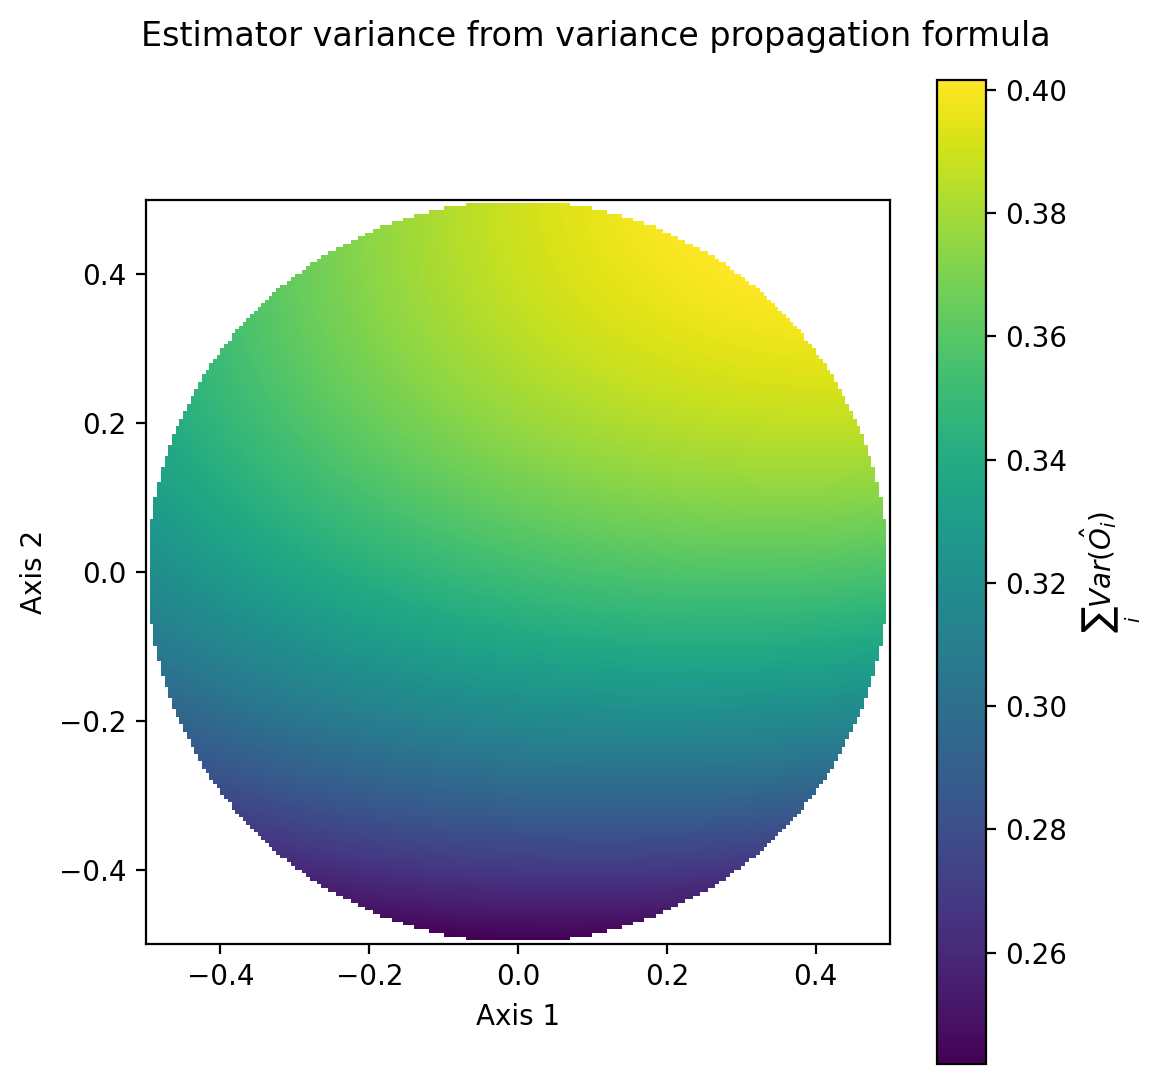

In [ ]:
from attr import evolve
import numpy as np
import matplotlib.pyplot as plt

#theta = np.pi / 2   # adjust tilt
#phi   = np.pi / 3   # adjust rotation
n = plane_from_angles(theta, phi)
u, v = plane_basis(n)

fig, ax = plt.subplots( figsize=(6,6), dpi=200)


# --- Grid in plane coordinates ---
res = 200
s = np.linspace(-0.5, 0.5, res)
t0 = np.linspace(-0.5, 0.5, res)
S, T = np.meshgrid(s, t0)

values = np.zeros_like(S)
mask = np.zeros_like(S, dtype=bool)

# --- Sample points in the plane ---
for i in range(res):
    for j in range(res):
        r = S[i, j] * u + T[i, j] * v

        if np.linalg.norm(r) <= 0.5:
            values[i, j] = np.sum([sum([coeff**2 * compute_scalar_var_eff(r, op, op_sqrd).real for coeff, op, op_sqrd in zip(qelms[3]._reg.coeff.T[i], evolved_ops[0], evolved_ops_sqrd[0])]) for i in range(3)]) 
            mask[i, j] = True
        else:
            values[i, j] = np.nan

# --- Plot ---
im = ax.imshow(values, extent=[-0.5,0.5,-0.5,0.5], origin='lower', cmap='viridis')
fig.colorbar(im, label=r'$\sum_i Var(\hat{O_i})$', ax=ax)
ax.set_xlabel('Axis 1')
ax.set_ylabel('Axis 2')

fig.suptitle(r'Estimator variance from variance propagation formula')
fig.subplots_adjust(top=0.93)


  0%|          | 0/30 [00:00<?, ?it/s]

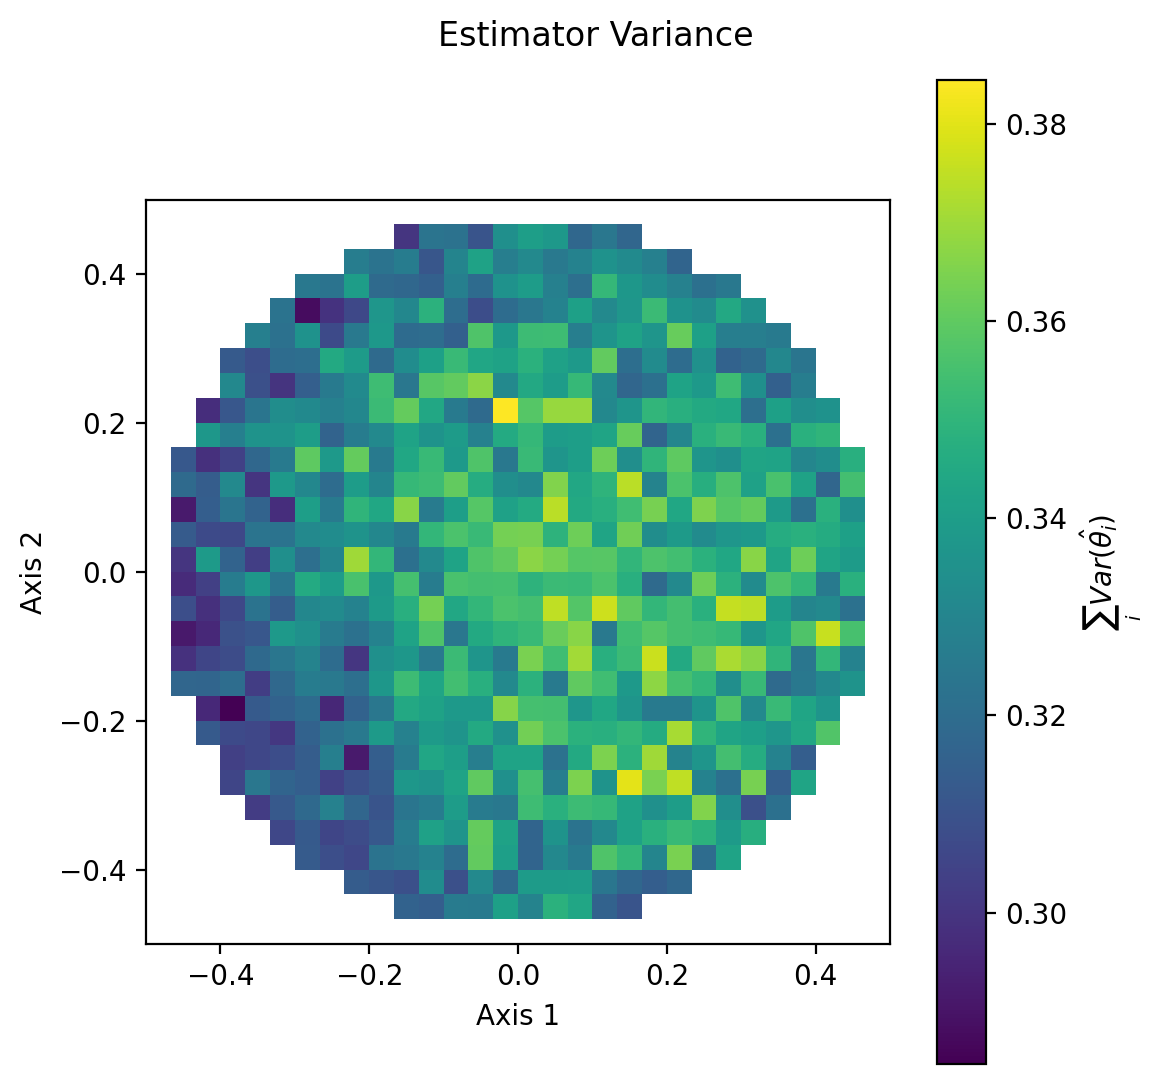

In [ ]:
from tqdm.auto import tqdm
  # adjust rotation
n = plane_from_angles(theta, phi)
u, v = plane_basis(n)

fig, ax = plt.subplots( figsize=(6,6), dpi=200)


# --- Grid in plane coordinates ---
res = 30
s = np.linspace(-0.5, 0.5, res)
t0 = np.linspace(-0.5, 0.5, res)
S, T = np.meshgrid(s, t0)

values = np.zeros_like(S)
mask = np.zeros_like(S, dtype=bool)

# --- Sample points in the plane ---
for i in tqdm(range(res)):
    for j in range(res):
        r = S[i, j] * u + T[i, j] * v

        if np.linalg.norm(r) <= 0.5:
            values[i, j] = np.sum(np.var(np.array([qelms[3].predict([DensityMatrix(bloch_to_density(r))])[0] - r for j in range(500)]), axis=0, ddof=1))*shots[3]
            mask[i, j] = True
        else:
            values[i, j] = np.nan

# --- Plot ---
im = ax.imshow(values, extent=[-0.5,0.5,-0.5,0.5], origin='lower', cmap='viridis')
fig.colorbar(im, label=r'$\sum_i Var(\hat{\theta_i})$', ax=ax)
ax.set_xlabel('Axis 1')
ax.set_ylabel('Axis 2')

fig.suptitle(r'Estimator Variance')
fig.subplots_adjust(top=0.93)


  0%|          | 0/20 [00:00<?, ?it/s]

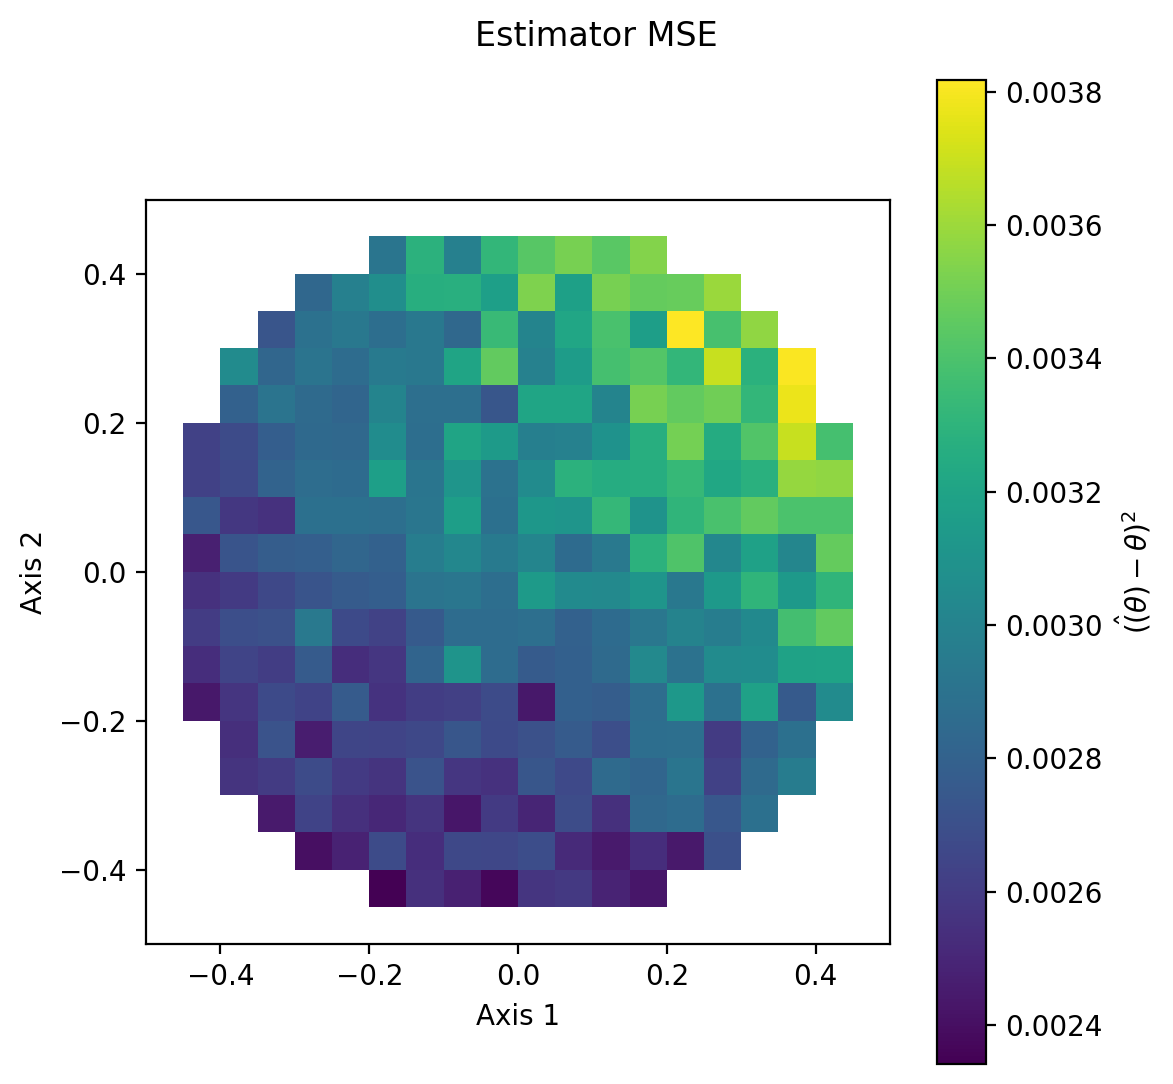

In [ ]:
from tqdm.auto import tqdm
  # adjust rotation
n = plane_from_angles(theta, phi)
u, v = plane_basis(n)

fig, ax = plt.subplots( figsize=(6,6), dpi=200)


# --- Grid in plane coordinates ---
res = 20
s = np.linspace(-0.5, 0.5, res)
t0 = np.linspace(-0.5, 0.5, res)
S, T = np.meshgrid(s, t0)

values = np.zeros_like(S)
mask = np.zeros_like(S, dtype=bool)

# --- Sample points in the plane ---
for i in tqdm(range(res)):
    for j in range(res):
        r = S[i, j] * u + T[i, j] * v

        if np.linalg.norm(r) <= 0.5:
            values[i, j] = np.sum(np.mean(np.array([qelms[2].predict([DensityMatrix(bloch_to_density(r))]) - r for j in range(500)])**2, axis=0))
            mask[i, j] = True
        else:
            values[i, j] = np.nan

# --- Plot ---
im = ax.imshow(values, extent=[-0.5,0.5,-0.5,0.5], origin='lower', cmap='viridis')
fig.colorbar(im, label=r'$(\hat(\theta) - \theta)^2$', ax=ax)
ax.set_xlabel('Axis 1')
ax.set_ylabel('Axis 2')

fig.suptitle(r'Estimator MSE')
fig.subplots_adjust(top=0.93)
